<a href="https://colab.research.google.com/github/Nousheen-code/-Integrative-Capstone-Project-and-Evaluation/blob/main/Integrative_Capstone_Project_and_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import kagglehub
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

import pandas as pd
import  os
print(os.listdir(path))
df=pd.read_csv(os.path.join(path,"Housing.csv"),sep=',')


Using Colab cache for faster access to the 'housing-prices-dataset' dataset.
['Housing.csv']


In [36]:
df.info()
df.describe()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [83]:
df.isnull().sum()
df.duplicated().sum()


np.int64(0)

In [38]:
df.shape
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [39]:
df.isnull().sum()


,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
df=df.drop_duplicates()
df.shape

(545, 13)

In [42]:
df.select_dtypes(include='object').columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [43]:
df.select_dtypes(include='number').columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')

In [44]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].unique())


mainroad:
['yes' 'no']

guestroom:
['no' 'yes']

basement:
['no' 'yes']

hotwaterheating:
['no' 'yes']

airconditioning:
['yes' 'no']

prefarea:
['yes' 'no']

furnishingstatus:
['furnished' 'semi-furnished' 'unfurnished']


In [45]:
yes_no_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in yes_no_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

In [46]:
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

In [47]:
df.head()
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,int64
guestroom,int64
basement,int64
hotwaterheating,int64
airconditioning,int64


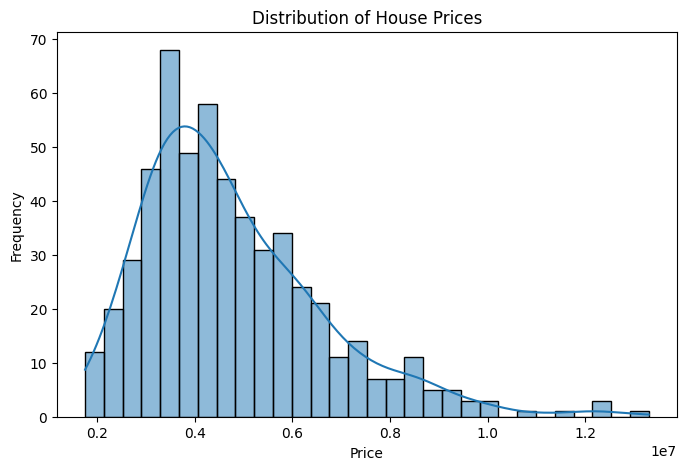

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

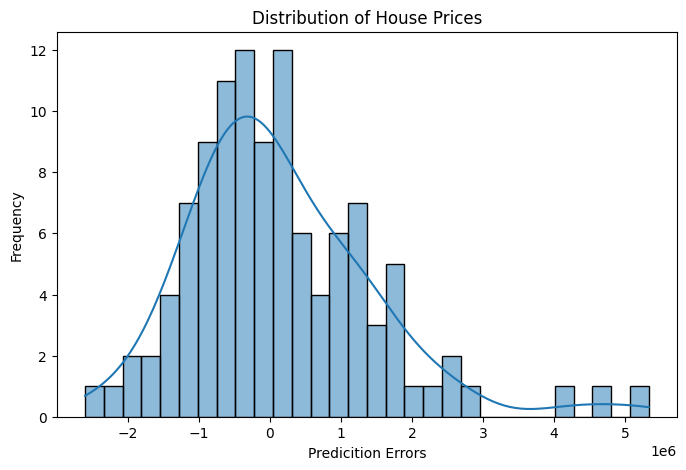

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(    comparison['Error'],
    bins=30,
    kde=True
)
plt.title('Distribution of House Prices')
plt.xlabel('Predicition Errors')
plt.ylabel('Frequency')
plt.show()

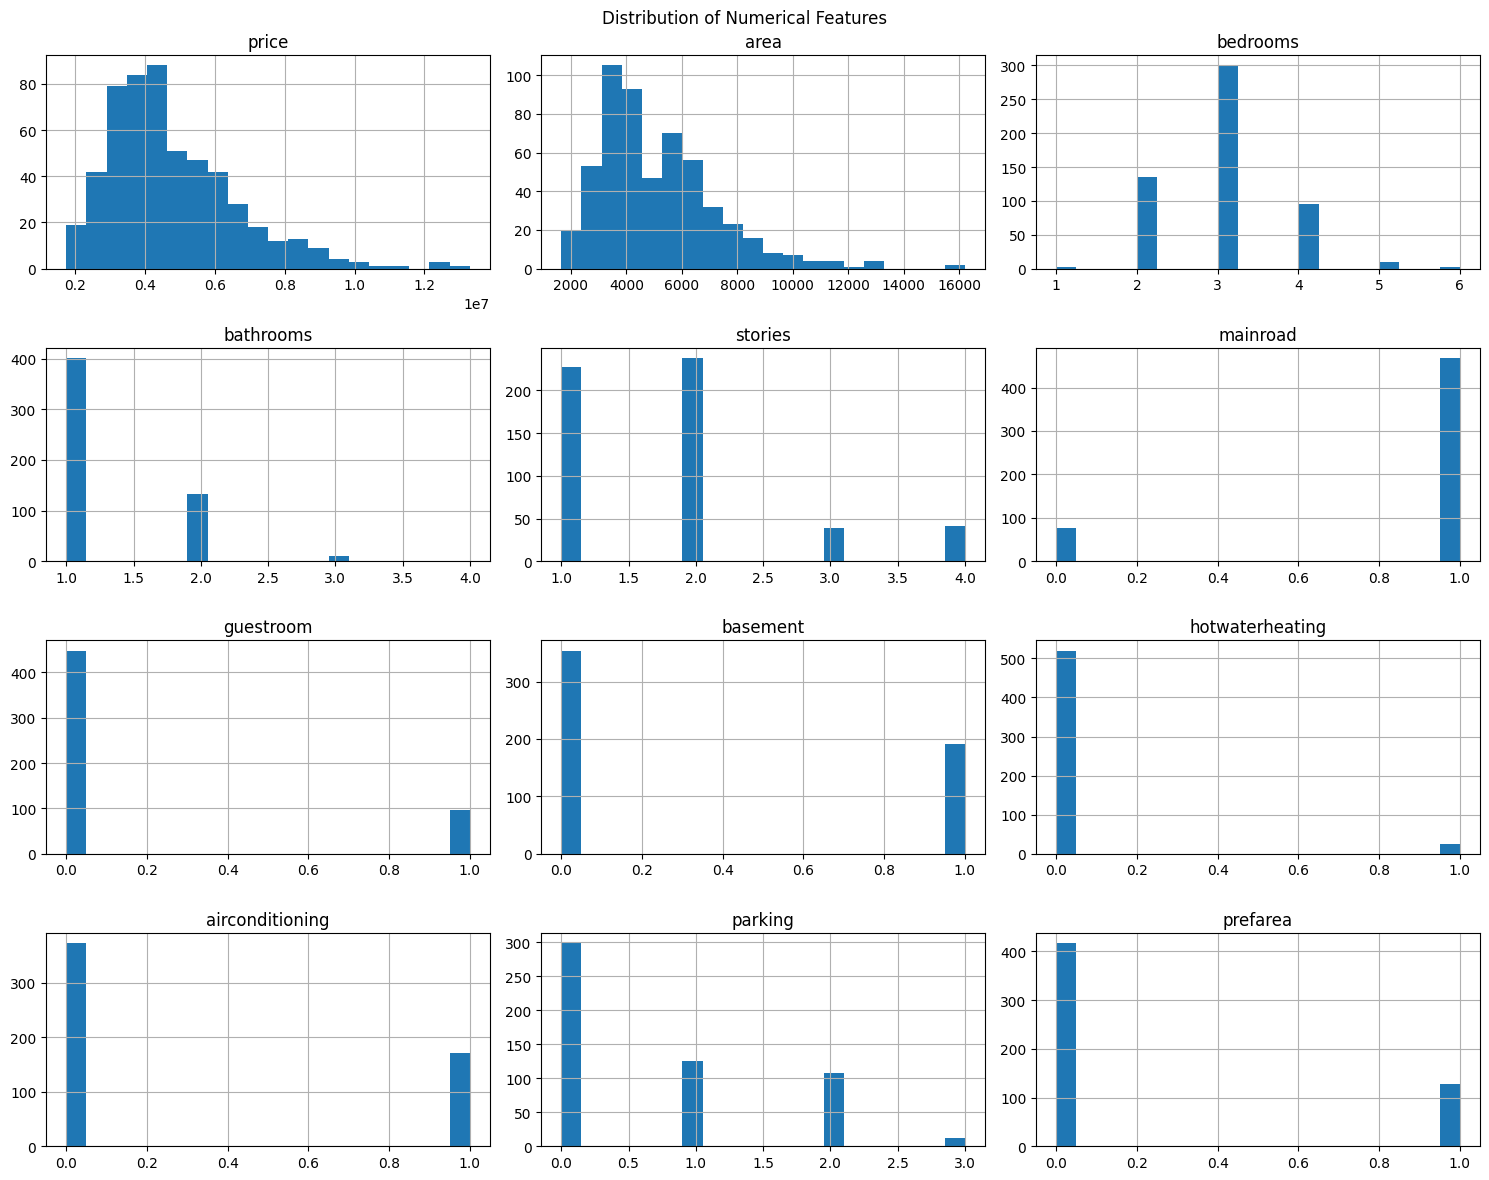

In [49]:
df.hist(figsize=(15, 12), bins=20)
plt.suptitle('Distribution of Numerical Features')
plt.tight_layout()
plt.show()

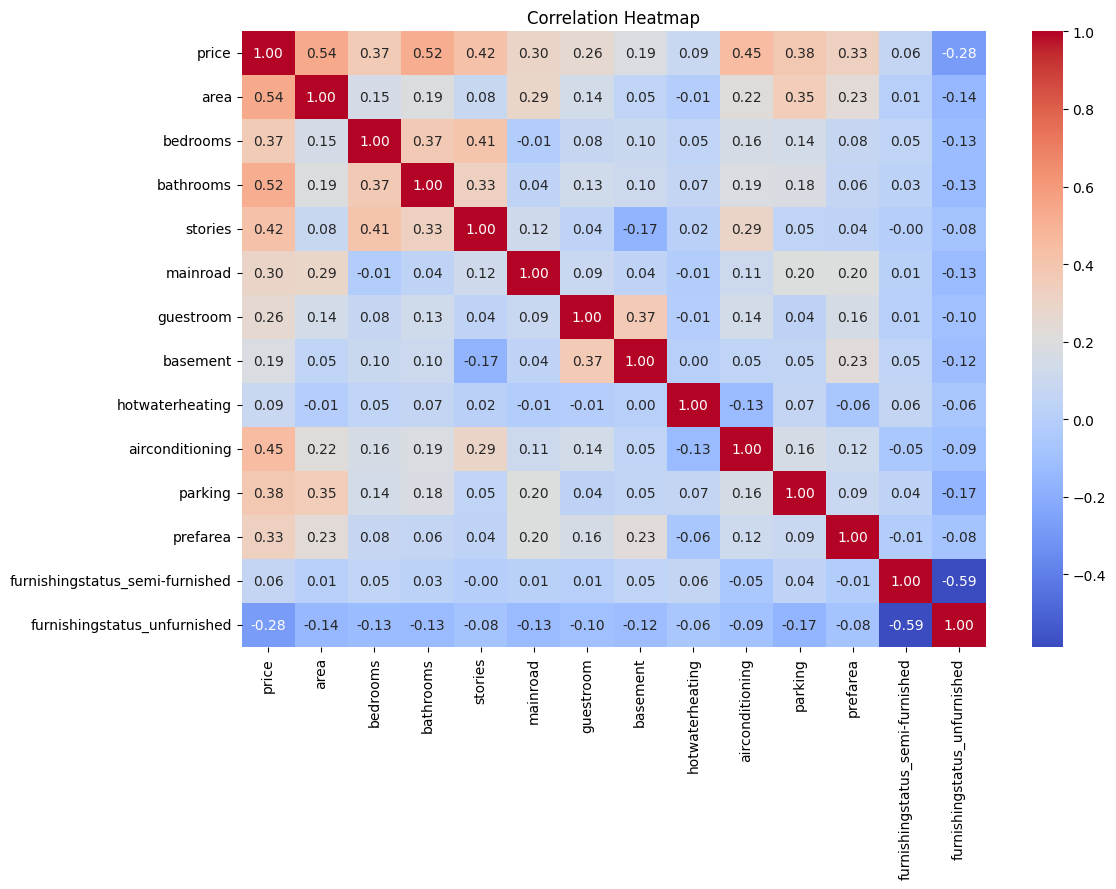

In [50]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [51]:
price_corr = correlation['price'].sort_values(ascending=False)

print(price_corr)

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


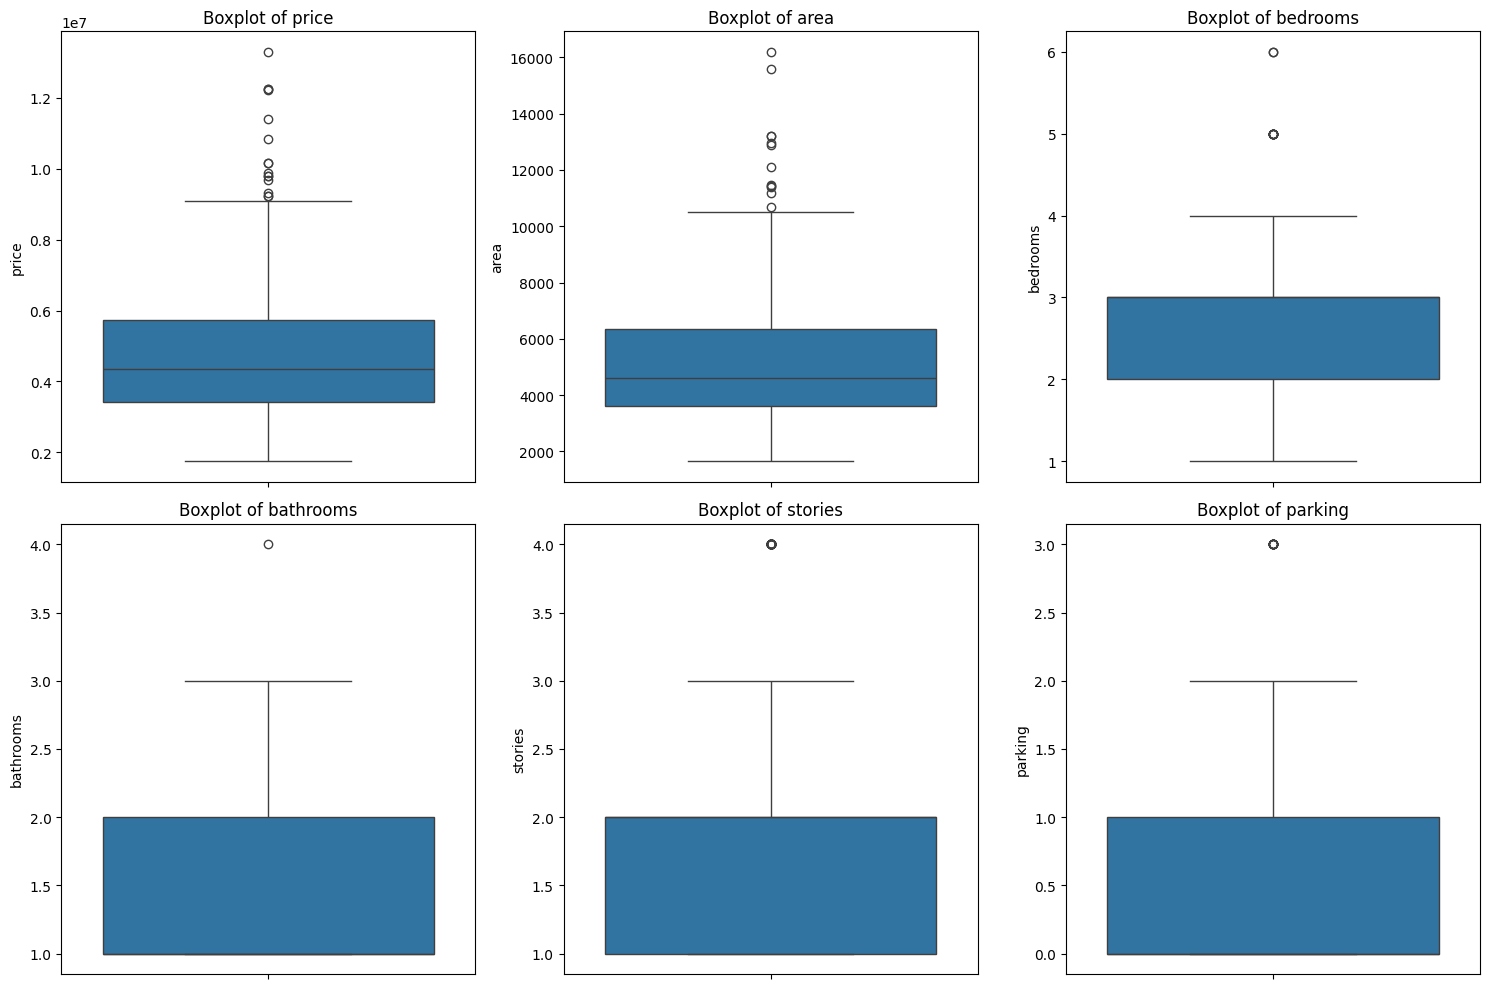

In [52]:
plt.figure(figsize=(15, 10))

numeric_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

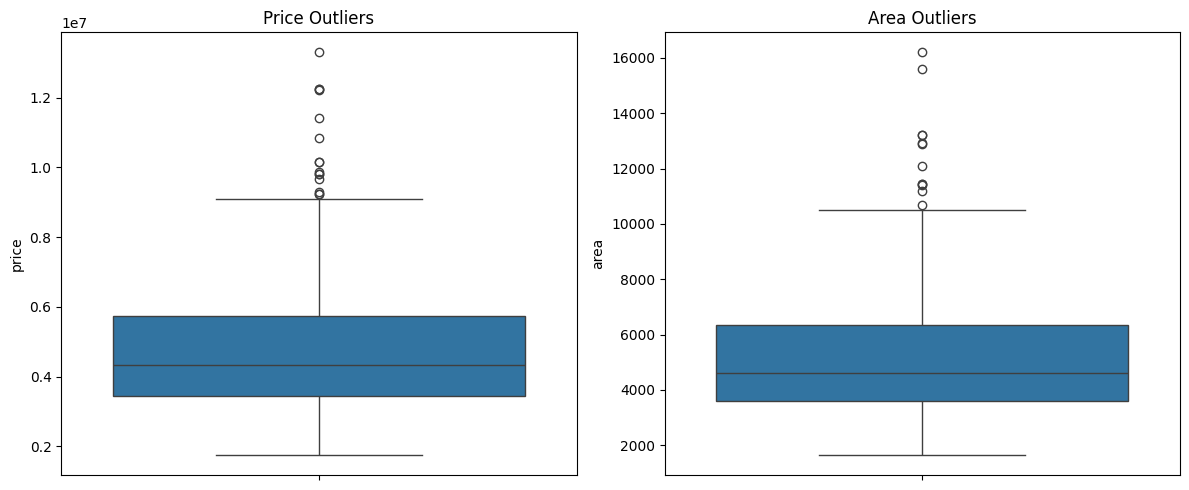

In [53]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['price'])
plt.title('Price Outliers')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['area'])
plt.title('Area Outliers')

plt.tight_layout()
plt.show()

In [54]:
Q1 = df[['price', 'area']].quantile(0.25)
Q3 = df[['price', 'area']].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bounds:")
print(lower_bound)

print("\nUpper Bounds:")
print(upper_bound)

Lower Bounds:
price   -35000.0
area      -540.0
dtype: float64

Upper Bounds:
price    9205000.0
area       10500.0
dtype: float64


In [55]:
outliers = ((df[['price', 'area']] < lower_bound) |
            (df[['price', 'area']] > upper_bound))

print("Number of potential outliers:")
print(outliers.sum())

Number of potential outliers:
price    15
area     12
dtype: int64


In [56]:
X = df.drop('price', axis=1)
y = df['price']

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (436, 13)
Testing data: (109, 13)


In [58]:
X_train = X_train.astype(int)
X_test = X_test.astype(int)

In [59]:
print(X_train.dtypes)

area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished    int64
furnishingstatus_unfurnished       int64
dtype: object


In [60]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

LinearRegression()

In [61]:
y_pred_linear = linear_model.predict(X_test)

In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("MAE:", mae_linear)
print("RMSE:", rmse_linear)
print("R² Score:", r2_linear)

Linear Regression Results
MAE: 970043.4039201637
RMSE: 1324506.9600914384
R² Score: 0.6529242642153185


In [63]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [64]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [65]:
y_pred_rf = rf_model.predict(X_test)

In [66]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Results
MAE: 1022560.0527522935
RMSE: 1401496.8425384816
R² Score: 0.6114024924156645


In [67]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_linear, mae_rf],
    'RMSE': [rmse_linear, rmse_rf],
    'R2 Score': [r2_linear, r2_rf]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.022560e+06,1.401497e+06,0.611402


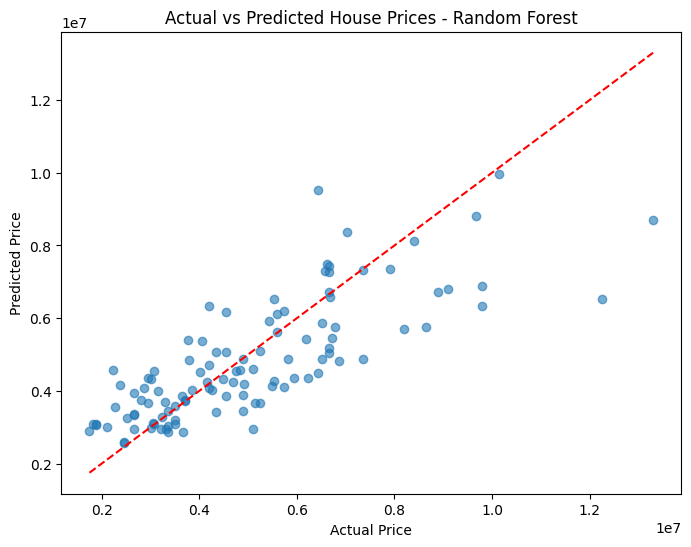

In [68]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.6)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices - Random Forest')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

In [69]:
results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.022560e+06,1.401497e+06,0.611402


In [70]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                            Feature  Importance
0                              area    0.467917
2                         bathrooms    0.151526
8                   airconditioning    0.062718
9                           parking    0.057820
3                           stories    0.057137
1                          bedrooms    0.048608
12     furnishingstatus_unfurnished    0.034998
6                          basement    0.030804
10                         prefarea    0.030519
7                   hotwaterheating    0.017255
5                         guestroom    0.016638
11  furnishingstatus_semi-furnished    0.013764
4                          mainroad    0.010296


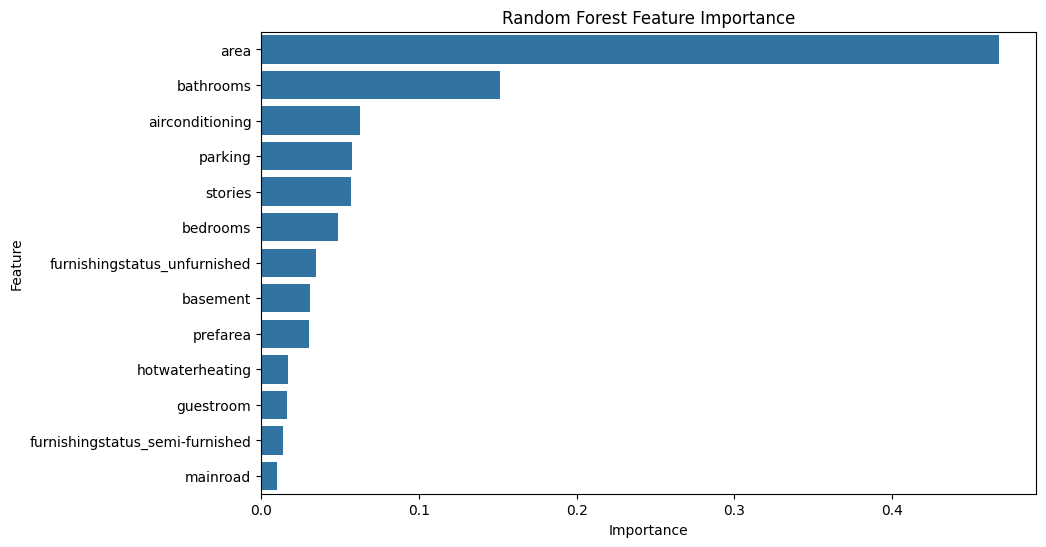

In [71]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [72]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': linear_model.coef_
})

coefficients['Absolute_Coefficient'] = coefficients['Coefficient'].abs()

coefficients = coefficients.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

print(coefficients)

                            Feature   Coefficient  Absolute_Coefficient
2                         bathrooms  1.094445e+06          1.094445e+06
8                   airconditioning  7.914267e+05          7.914267e+05
7                   hotwaterheating  6.846499e+05          6.846499e+05
10                         prefarea  6.298906e+05          6.298906e+05
12     furnishingstatus_unfurnished -4.136451e+05          4.136451e+05
3                           stories  4.074766e+05          4.074766e+05
6                          basement  3.902512e+05          3.902512e+05
4                          mainroad  3.679199e+05          3.679199e+05
5                         guestroom  2.316100e+05          2.316100e+05
9                           parking  2.248419e+05          2.248419e+05
11  furnishingstatus_semi-furnished -1.268818e+05          1.268818e+05
1                          bedrooms  7.677870e+04          7.677870e+04
0                              area  2.359688e+02          2.359

In [73]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                            Feature  Importance
0                              area    0.467917
2                         bathrooms    0.151526
8                   airconditioning    0.062718
9                           parking    0.057820
3                           stories    0.057137
1                          bedrooms    0.048608
12     furnishingstatus_unfurnished    0.034998
6                          basement    0.030804
10                         prefarea    0.030519
7                   hotwaterheating    0.017255
5                         guestroom    0.016638
11  furnishingstatus_semi-furnished    0.013764
4                          mainroad    0.010296


In [76]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred_linear
})

comparison.head(10)

,Actual Price,Predicted Price
0,4060000,5.164654e+06
1,6650000,7.224722e+06
2,3710000,3.109863e+06
3,6440000,4.612075e+06
4,2800000,3.294646e+06
5,4900000,3.532275e+06
6,5250000,5.611775e+06
7,4543000,6.368146e+06
8,2450000,2.722857e+06
9,3353000,2.629406e+06


In [77]:
comparison['Error'] = (
    comparison['Actual Price'] -
    comparison['Predicted Price']
)

comparison.head(10)

,Actual Price,Predicted Price,Error
0,4060000,5.164654e+06,-1.104654e+06
1,6650000,7.224722e+06,-5.747223e+05
2,3710000,3.109863e+06,6.001368e+05
3,6440000,4.612075e+06,1.827925e+06
4,2800000,3.294646e+06,-4.946463e+05
5,4900000,3.532275e+06,1.367725e+06
6,5250000,5.611775e+06,-3.617746e+05
7,4543000,6.368146e+06,-1.825146e+06
8,2450000,2.722857e+06,-2.728570e+05
9,3353000,2.629406e+06,7.235944e+05


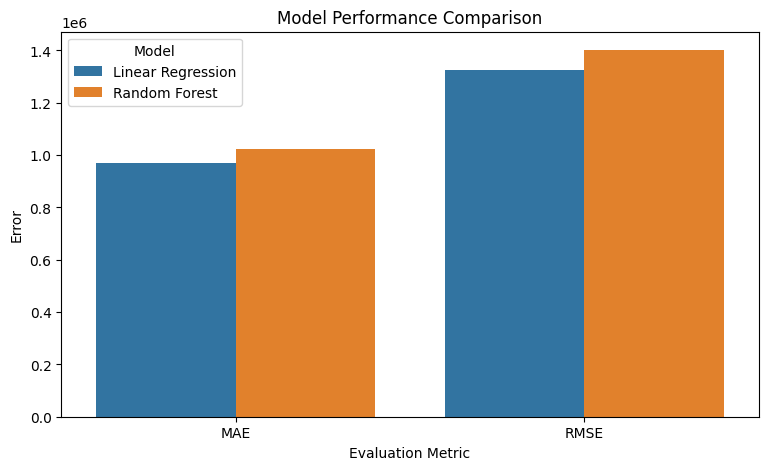

In [78]:
results_melted = results.melt(
    id_vars='Model',
    value_vars=['MAE', 'RMSE'],
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_melted,
    x='Metric',
    y='Value',
    hue='Model'
)

plt.title('Model Performance Comparison')
plt.ylabel('Error')
plt.xlabel('Evaluation Metric')

plt.show()

In [79]:
comparison.head(10)

,Actual Price,Predicted Price,Error
0,4060000,5.164654e+06,-1.104654e+06
1,6650000,7.224722e+06,-5.747223e+05
2,3710000,3.109863e+06,6.001368e+05
3,6440000,4.612075e+06,1.827925e+06
4,2800000,3.294646e+06,-4.946463e+05
5,4900000,3.532275e+06,1.367725e+06
6,5250000,5.611775e+06,-3.617746e+05
7,4543000,6.368146e+06,-1.825146e+06
8,2450000,2.722857e+06,-2.728570e+05
9,3353000,2.629406e+06,7.235944e+05


In [80]:
comparison['Error'].describe()

,Error
count,1.090000e+02
mean,1.460554e+05
std,1.322510e+06
min,-2.603188e+06
25%,-7.023621e+05
50%,-8.189880e+04
75%,9.234027e+05
max,5.331724e+06


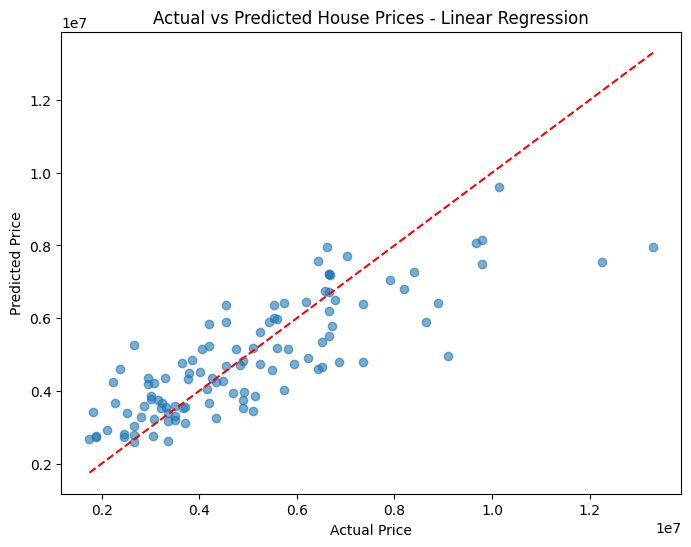

In [81]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_linear, alpha=0.6)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices - Linear Regression')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()